In [ ]:
import os
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import sys
import matplotlib.pyplot as plt

project_root = Path(os.getcwd()).parent
print(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

SAVE_DIR = project_root / "experiments" / "cva_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

from src.utils.seed import set_seed
set_seed(42)

from src.data.preprocessing.pipeline import Pipeline
from src.data.datasets.universal_dataset import CVADataset
from src.data.preprocessing.base.raw_data_extractor import RawDataExtractor


/mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF


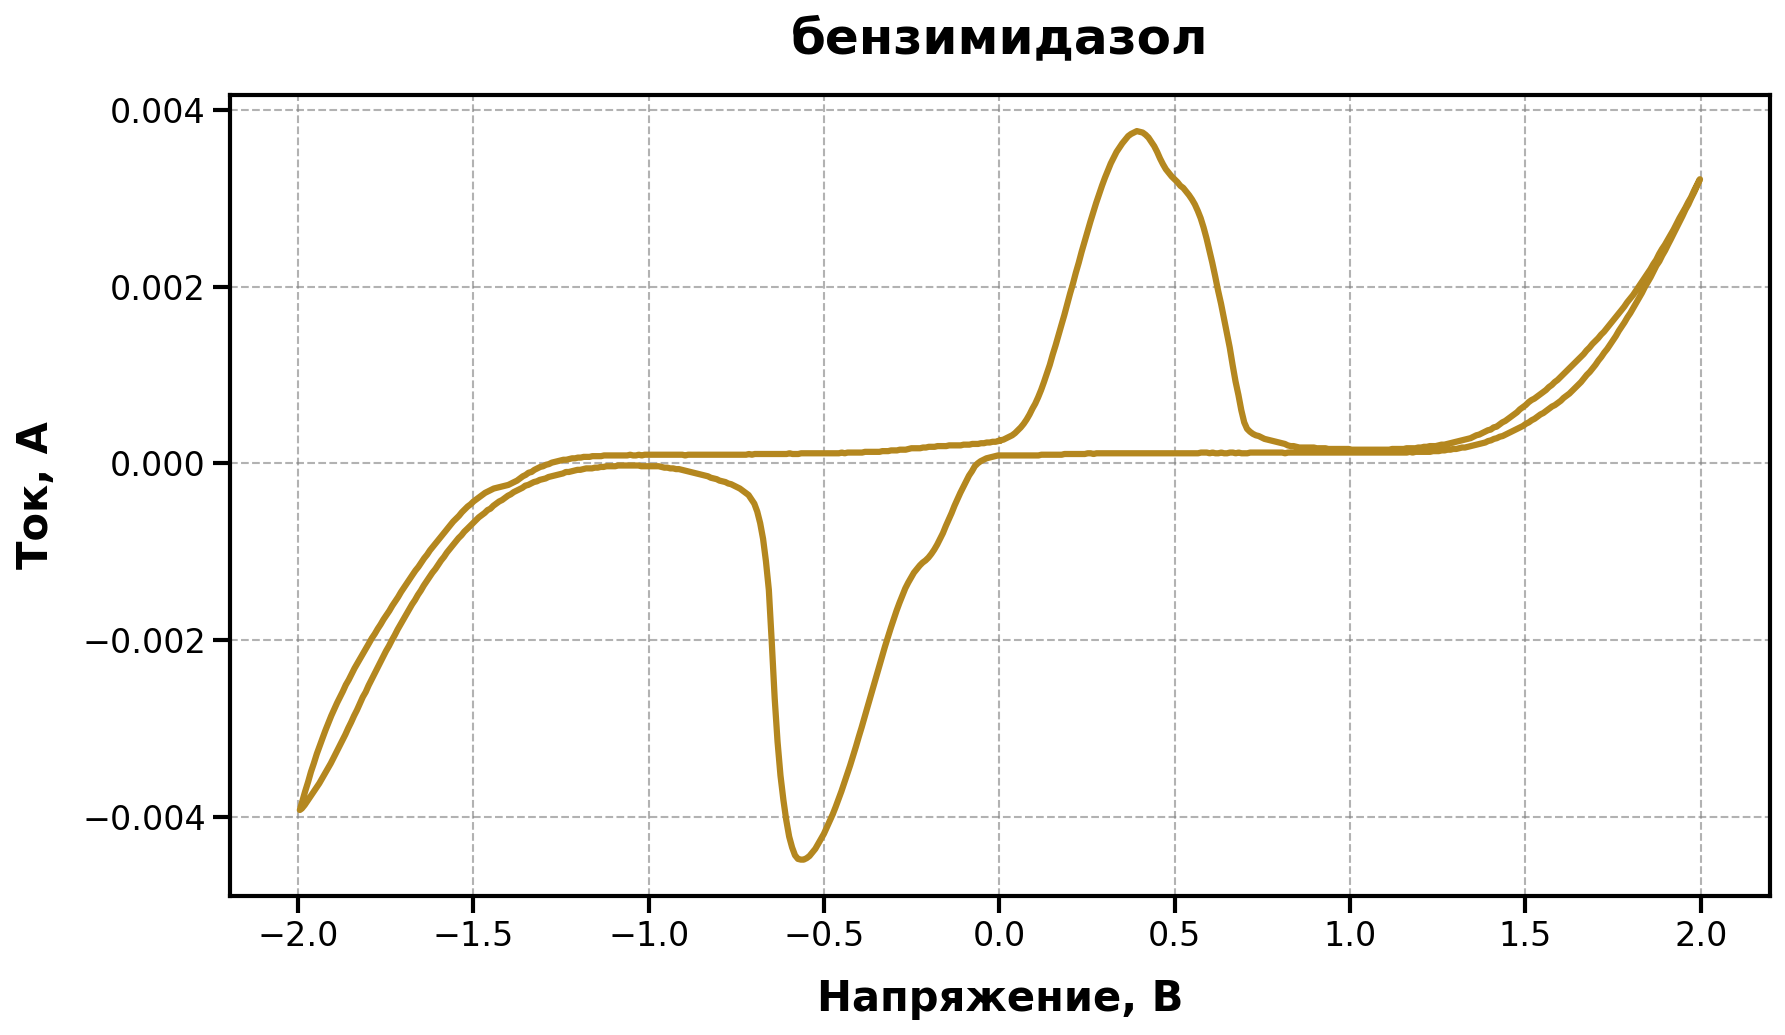

In [ ]:
TARGET_INHIBITOR = "benzimidazole"
TARGET_CYCLE = 3
SAMPLE_INDEX = 3

inhibitor_names_ru = {
    '4-benzylpiperidine': '4-бензилпиперидин',
    '2-mercaptobenzimidazole': '2-меркаптобензимидазол',
    'benzotriazole': 'бензотриазол',
    'benzimidazole': 'бензимидазол'
}

extractor = RawDataExtractor(split="all")

df_meta = extractor.metadata
raw_voltages = extractor.voltage_raw
raw_currents = extractor.current_raw

mask = (df_meta['Inhibitor'] == TARGET_INHIBITOR) & (df_meta['Num_of_Cycle'] == TARGET_CYCLE)
filtered_indices = df_meta[mask].index.tolist()

if not filtered_indices:
    print(f" Не найдено графиков для ингибитора '{TARGET_INHIBITOR}' и цикла {TARGET_CYCLE}.")
else:
    total_samples = len(filtered_indices)
    
    if SAMPLE_INDEX >= total_samples:
        print(f"Ошибка: SAMPLE_INDEX = {SAMPLE_INDEX} слишком большой. Максимум: {total_samples - 1}.")
    else:
        target_idx = filtered_indices[SAMPLE_INDEX]
        
        v_plot = raw_voltages[target_idx]
        c_plot = raw_currents[target_idx]
        ppm_val = df_meta.loc[target_idx, 'ppm']
        
        name_ru = inhibitor_names_ru.get(TARGET_INHIBITOR, TARGET_INHIBITOR)
        
        fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
        
        ax.plot(v_plot, c_plot, color="#B4871F", linewidth=3)
        
        ax.set_title(name_ru, fontsize=24, fontweight='bold', pad=20)
        ax.set_xlabel("Напряжение, В", fontsize=20, fontweight='bold', labelpad=12)
        ax.set_ylabel("Ток, А", fontsize=20, fontweight='bold', labelpad=12)
        
        ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
        
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        
        ax.grid(True, linestyle='--', linewidth=1, alpha=0.6, color='gray')
        
        plt.tight_layout()
        plt.show()

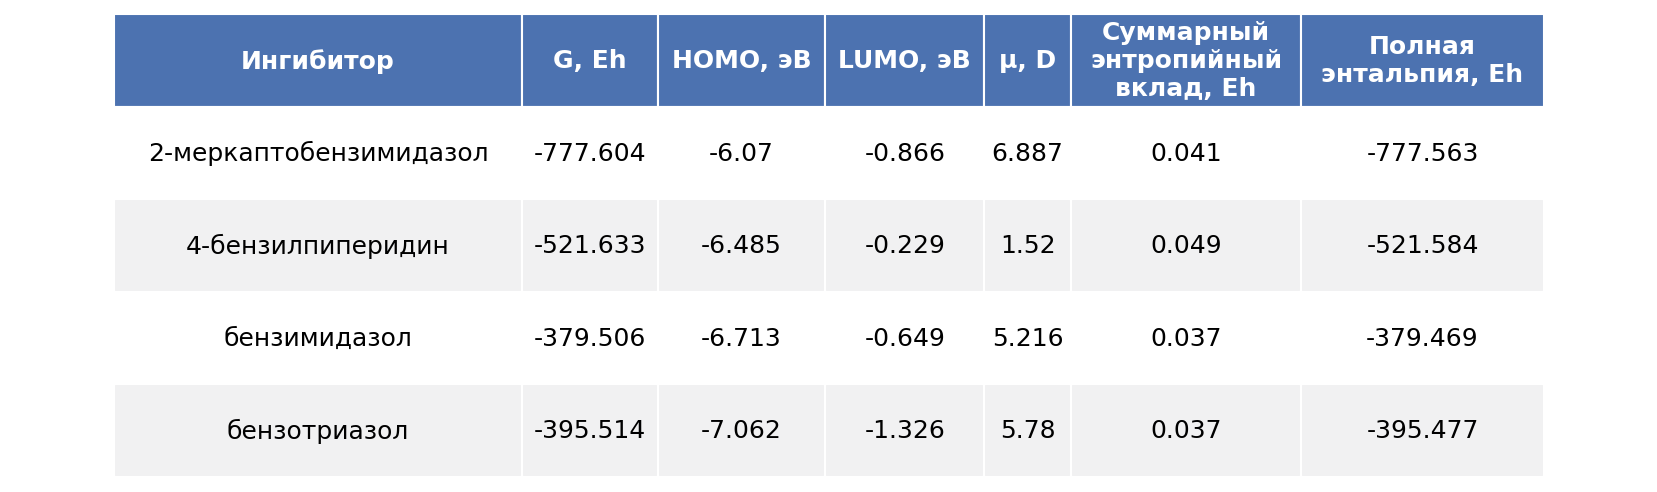

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Ингибитор": [
        "2-меркаптобензимидазол", 
        "4-бензилпиперидин", 
        "бензимидазол", 
        "бензотриазол"
    ],
    "G, Eh": [-777.604, -521.633, -379.506, -395.514],
    "HOMO, эВ": [-6.070, -6.485, -6.713, -7.062],
    "LUMO, эВ": [-0.866, -0.229, -0.649, -1.326],
    "μ, D": [6.887, 1.520, 5.216, 5.780],
    "Суммарный\nэнтропийный\nвклад, Eh": [0.041, 0.049, 0.037, 0.037],
    "Полная\nэнтальпия, Eh": [-777.563, -521.584, -379.469, -395.477]
}

df = pd.DataFrame(data)

def create_dynamic_table(df, save_path=None):
    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    ax.axis('off')
    
    table = ax.table(
        cellText=df.values, 
        colLabels=df.columns, 
        loc='center', 
        cellLoc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    
    table.auto_set_column_width(col=list(range(len(df.columns))))
    
    table.scale(1.2, 3.7)
    header_color = '#4C72B0'
    row_colors = ['#f1f1f2', 'white']
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('white')
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor(header_color)
        else:
            cell.set_facecolor(row_colors[row % len(row_colors)])
    save_path = SAVE_DIR / "DFT_table.png"     
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

create_dynamic_table(df, SAVE_DIR)